# Experiment: LargeST GLA Exploration

This notebook is the first real exploratory analysis pass for the LargeST Greater Los Angeles (GLA) subset.

Goals:
- load the generated 2019 GLA traffic flow data, metadata, and road-network adjacency
- profile temporal coverage, node count, graph size, and missing / zero-heavy behavior
- inspect a few sensors over time and look for daily / monthly patterns
- compare LargeST-GLA against our current METR-LA benchmark to decide whether we should switch


In [11]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tables

plt.style.use("ggplot")
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 140)


## Locate the LargeST-GLA files

We expect the generated GLA subset to live under `data/raw/LargeST/gla/` after running the official preprocessing notebooks.


In [12]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    return start


repo_root = find_repo_root(Path.cwd())
gla_root = repo_root / "data" / "raw" / "LargeST" / "gla"
flow_path = gla_root / "gla_his_2019.h5"
meta_path = gla_root / "gla_meta.csv"
adj_path = gla_root / "gla_rn_adj.npy"
metr_la_path = repo_root / "data" / "raw" / "METR-LA-Complete" / "metr-la.h5"

for path in [flow_path, meta_path, adj_path]:
    print(path.name, path.exists(), path)

if not all(path.exists() for path in [flow_path, meta_path, adj_path]):
    raise FileNotFoundError("LargeST-GLA files are missing. Run the LargeST preprocessing notebooks first.")


gla_his_2019.h5 True /Users/jerry/Projects/School/intellipath-ml/data/raw/LargeST/gla/gla_his_2019.h5
gla_meta.csv True /Users/jerry/Projects/School/intellipath-ml/data/raw/LargeST/gla/gla_meta.csv
gla_rn_adj.npy True /Users/jerry/Projects/School/intellipath-ml/data/raw/LargeST/gla/gla_rn_adj.npy


## Load flow, metadata, and graph artifacts

The generated GLA flow file contains one year of 15-minute data. The metadata file carries sensor attributes and district membership, and the adjacency matrix represents the road-network graph.


In [13]:
flow = pd.read_hdf(flow_path, key="t")
flow.index = pd.to_datetime(flow.index)
flow = flow.sort_index()

meta = pd.read_csv(meta_path)
adj = np.load(adj_path)

flow.shape, meta.shape, adj.shape


((35040, 3834), (3834, 10), (3834, 3834))

## Dataset summary

This gives us the project-level numbers we care about first: time span, sampling interval, node count, graph size, and value distribution.


In [14]:
time_deltas = flow.index.to_series().diff().dropna()
sampling_interval = time_deltas.mode().iloc[0] if not time_deltas.empty else pd.NaT
flow_values = flow.to_numpy()
num_edges = int(np.count_nonzero(adj) - np.count_nonzero(np.diag(adj)))
graph_density = num_edges / (adj.shape[0] * (adj.shape[0] - 1))

summary = pd.Series(
    {
        "num_timesteps": flow.shape[0],
        "num_nodes": flow.shape[1],
        "time_start": str(flow.index.min()),
        "time_end": str(flow.index.max()),
        "sampling_interval": str(sampling_interval),
        "missing_values": int(flow.isna().sum().sum()),
        "zero_fraction": float(np.mean(flow_values == 0)),
        "mean_flow_value": float(flow_values.mean()),
        "std_flow_value": float(flow_values.std()),
        "graph_edges_no_diag": num_edges,
        "graph_density_no_diag": float(graph_density),
    }
)

display(summary.to_frame("value"))


,value
num_timesteps,35040
num_nodes,3834
time_start,2019-01-01 00:00:00
time_end,2019-12-31 23:45:00
sampling_interval,0 days 00:15:00
missing_values,0
zero_fraction,0.018487
mean_flow_value,276.823953
std_flow_value,187.773287
graph_edges_no_diag,98703


## Metadata overview

This tells us where the sensors come from and whether the subset really matches the Greater Los Angeles framing.


In [15]:
district_counts = meta["District"].value_counts().sort_index()
county_counts = meta["County"].value_counts().sort_values(ascending=False).head(10)
fwy_counts = meta["Fwy"].value_counts().sort_values(ascending=False).head(10)

display(meta.head())
display(district_counts.to_frame("sensor_count"))
display(county_counts.to_frame("sensor_count"))
display(fwy_counts.to_frame("sensor_count"))


,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,767494,34.103332,-118.249733,7,Los Angeles,SR2-E,3,Mainline,E,3527
1,767509,34.107693,-118.249538,7,Los Angeles,SR2-E,4,Mainline,E,3528
2,767523,34.113959,-118.242956,7,Los Angeles,SR2-E,4,Mainline,E,3529
3,767541,34.116060,-118.238384,7,Los Angeles,SR2-E,4,Mainline,E,3530
4,767554,34.121074,-118.229892,7,Los Angeles,SR2-E,4,Mainline,E,3531


,sensor_count
District,
7,1859
8,1022
12,953


,sensor_count
County,
Los Angeles,1728
Orange,953
San Bernardino,540
Riverside,482
Ventura,131


,sensor_count
Fwy,
I10-W,244
I10-E,243
I5-S,205
I5-N,197
I405-S,169
I405-N,160
I210-W,148
I15-N,147
I15-S,144


## Graph overview

The adjacency matrix is large, so we summarize it through degree statistics and a small matrix preview.


In [16]:
adj_binary = adj != 0
out_degree = adj_binary.sum(axis=1) - np.diag(adj_binary).astype(int)
graph_stats = pd.Series(
    {
        "min_degree": int(out_degree.min()),
        "median_degree": float(np.median(out_degree)),
        "mean_degree": float(out_degree.mean()),
        "max_degree": int(out_degree.max()),
    }
)

degree_table = meta[["ID", "District", "County", "Fwy", "Direction"]].copy()
degree_table["degree"] = out_degree
degree_table = degree_table.sort_values("degree", ascending=False)

display(graph_stats.to_frame("value"))
display(degree_table.head(10))
display(pd.DataFrame(adj[:5, :5]))


,value
min_degree,0.000000
median_degree,23.000000
mean_degree,25.744131
max_degree,85.000000


,ID,District,County,Fwy,Direction,degree
554,717265,7,Los Angeles,SR60-E,E,85
624,717270,7,Los Angeles,SR60-W,W,82
622,717266,7,Los Angeles,SR60-W,W,81
623,717269,7,Los Angeles,SR60-W,W,81
1856,718017,7,Los Angeles,I710-S,S,78
1821,718016,7,Los Angeles,I710-N,N,76
1857,718018,7,Los Angeles,I710-S,S,76
3127,1202949,12,Orange,SR22-E,E,75
555,717268,7,Los Angeles,SR60-E,E,75
1819,776221,7,Los Angeles,I710-N,N,75


,0,1,2,3,4
0,1.000000,0.988261,0.899386,0.828356,0.654618
1,0.180545,1.000000,0.954013,0.899597,0.745245
2,0.050767,0.172985,1.000000,0.988338,0.899597
3,0.072929,0.227784,0.328125,1.000000,0.954013
4,0.000000,0.000000,0.012506,0.060366,1.000000


## Sample sensor time series

A short visual sample helps us see whether the series are stable enough for forecasting and whether the resampled values behave sensibly.


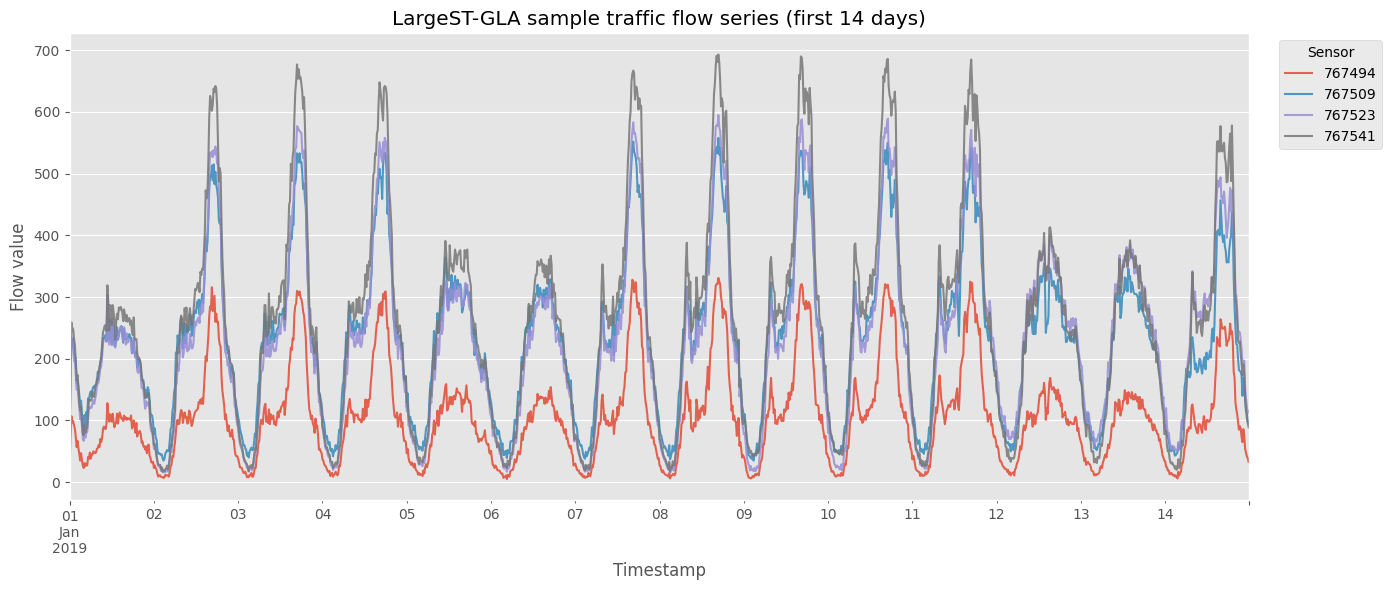

In [17]:
sample_sensor_count = min(4, flow.shape[1])
sample_sensors = list(flow.columns[:sample_sensor_count])

ax = flow[sample_sensors].iloc[: 96 * 14].plot(figsize=(14, 6), alpha=0.85)
ax.set_title("LargeST-GLA sample traffic flow series (first 14 days)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Flow value")
plt.legend(title="Sensor", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


## Daily and monthly patterns

These aggregates give us a feel for cyclic structure, which is useful for simple baselines and feature engineering.


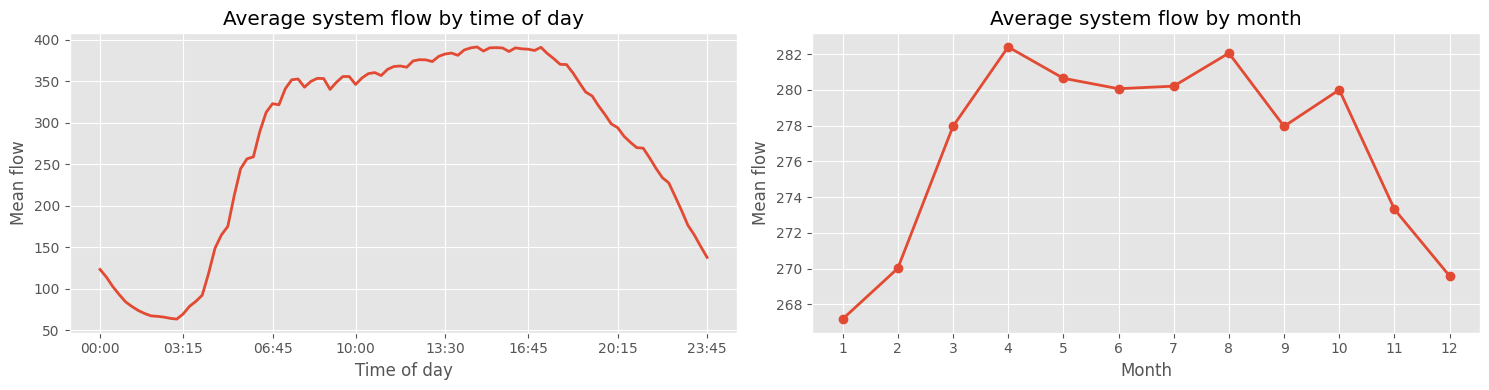

In [18]:
system_mean_series = flow.mean(axis=1)
average_by_time = system_mean_series.groupby(flow.index.time).mean()
average_by_month = system_mean_series.groupby(flow.index.month).mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

tick_positions = np.linspace(0, len(average_by_time) - 1, 8, dtype=int)
axes[0].plot(range(len(average_by_time)), average_by_time.values, linewidth=2)
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels([average_by_time.index[i].strftime("%H:%M") for i in tick_positions])
axes[0].set_title("Average system flow by time of day")
axes[0].set_xlabel("Time of day")
axes[0].set_ylabel("Mean flow")

axes[1].plot(average_by_month.index, average_by_month.values, marker="o", linewidth=2)
axes[1].set_title("Average system flow by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean flow")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()


## Geographic comparison with METR-LA

This is a coordinate-based map view rather than a tiled street map, but it is enough to compare footprint and sensor overlap. A strong sign in favor of switching is whether METR-LA is mostly embedded inside the GLA subset rather than being a completely different network.


In [19]:
metr_locations = pd.read_csv(repo_root / "data" / "raw" / "METR-LA-Complete" / "graph_sensor_locations.csv")
metr_locations = metr_locations.rename(columns={"sensor_id": "ID", "latitude": "Lat", "longitude": "Lng"})
metr_locations["ID"] = metr_locations["ID"].astype(str)

gla_locations = meta[["ID", "Lat", "Lng", "District", "County", "Fwy", "Direction"]].copy()
gla_locations["ID"] = gla_locations["ID"].astype(str)

shared_ids = set(metr_locations["ID"]) & set(gla_locations["ID"])
metr_locations["shared_with_gla"] = metr_locations["ID"].isin(shared_ids)
gla_locations["shared_with_metr_la"] = gla_locations["ID"].isin(shared_ids)

geo_summary = pd.Series(
    {
        "metr_la_sensor_count": int(len(metr_locations)),
        "largest_gla_sensor_count": int(len(gla_locations)),
        "shared_sensor_ids": int(len(shared_ids)),
        "metr_la_coverage_inside_gla": float(len(shared_ids) / len(metr_locations)),
    }
)

display(geo_summary.to_frame("value"))


,value
metr_la_sensor_count,207.000000
largest_gla_sensor_count,3834.000000
shared_sensor_ids,201.000000
metr_la_coverage_inside_gla,0.971014


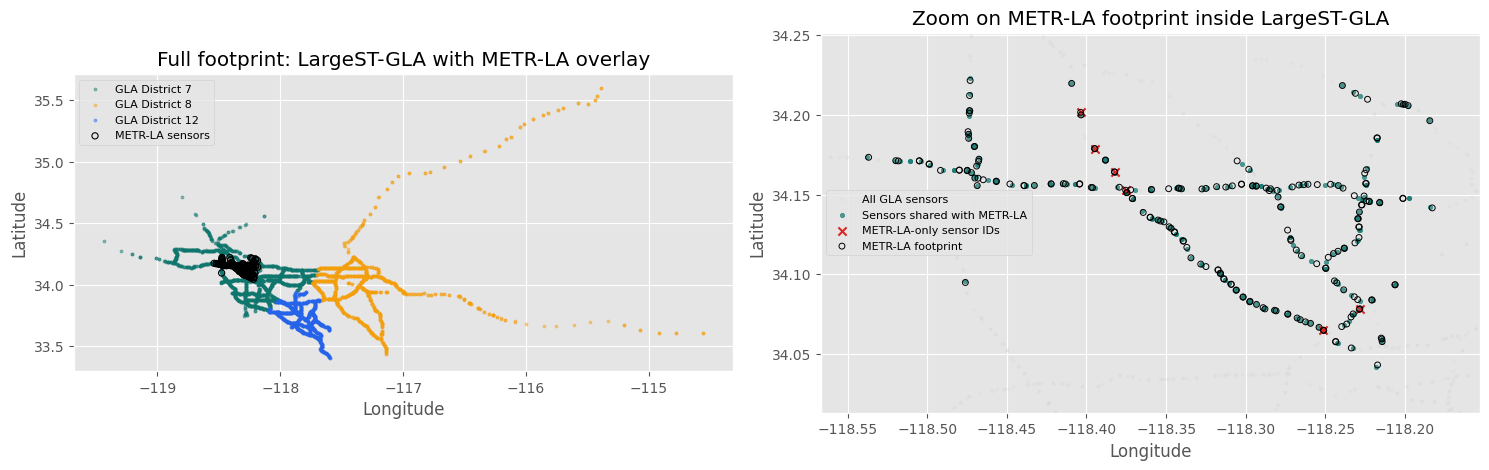

In [20]:
district_palette = {7: "#0f766e", 8: "#f59e0b", 12: "#2563eb"}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for district, group in gla_locations.groupby("District"):
    axes[0].scatter(
        group["Lng"],
        group["Lat"],
        s=5,
        alpha=0.45,
        color=district_palette.get(district, "gray"),
        label=f"GLA District {district}",
    )
axes[0].scatter(
    metr_locations["Lng"],
    metr_locations["Lat"],
    s=20,
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    label="METR-LA sensors",
)
axes[0].set_title("Full footprint: LargeST-GLA with METR-LA overlay")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend(loc="best", fontsize=8)

axes[1].scatter(gla_locations["Lng"], gla_locations["Lat"], s=4, color="lightgray", alpha=0.15, label="All GLA sensors")
axes[1].scatter(
    gla_locations.loc[gla_locations["shared_with_metr_la"], "Lng"],
    gla_locations.loc[gla_locations["shared_with_metr_la"], "Lat"],
    s=10,
    color="#0f766e",
    alpha=0.7,
    label="Sensors shared with METR-LA",
)
axes[1].scatter(
    metr_locations.loc[~metr_locations["shared_with_gla"], "Lng"],
    metr_locations.loc[~metr_locations["shared_with_gla"], "Lat"],
    s=35,
    color="#dc2626",
    marker="x",
    label="METR-LA-only sensor IDs",
)
axes[1].scatter(
    metr_locations["Lng"],
    metr_locations["Lat"],
    s=18,
    facecolors="none",
    edgecolors="black",
    linewidths=0.7,
    label="METR-LA footprint",
)
axes[1].set_xlim(metr_locations["Lng"].min() - 0.03, metr_locations["Lng"].max() + 0.03)
axes[1].set_ylim(metr_locations["Lat"].min() - 0.03, metr_locations["Lat"].max() + 0.03)
axes[1].set_title("Zoom on METR-LA footprint inside LargeST-GLA")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].legend(loc="best", fontsize=8)

for ax in axes:
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()


## Compare LargeST-GLA with METR-LA

We do a quick size and coverage comparison so the project decision is grounded in the actual artifacts we have locally.


In [21]:
def load_metr_la_hdf(path: Path) -> pd.DataFrame:
    with tables.open_file(path, mode="r") as h5_file:
        node = h5_file.root.df
        values = node.block0_values.read()
        columns = [
            col.decode() if isinstance(col, (bytes, bytearray)) else str(col)
            for col in node.axis0.read()
        ]
        index = pd.to_datetime(node.axis1.read())
    return pd.DataFrame(values, index=index, columns=columns).sort_index()


metr_la = load_metr_la_hdf(metr_la_path)
comparison = pd.DataFrame(
    {
        "METR-LA": {
            "num_timesteps": metr_la.shape[0],
            "num_nodes": metr_la.shape[1],
            "time_start": str(metr_la.index.min()),
            "time_end": str(metr_la.index.max()),
            "coverage_days": int((metr_la.index.max() - metr_la.index.min()).days + 1),
        },
        "LargeST-GLA": {
            "num_timesteps": flow.shape[0],
            "num_nodes": flow.shape[1],
            "time_start": str(flow.index.min()),
            "time_end": str(flow.index.max()),
            "coverage_days": int((flow.index.max() - flow.index.min()).days + 1),
        },
    }
)

display(comparison)


,METR-LA,LargeST-GLA
num_timesteps,34272,35040
num_nodes,207,3834
time_start,2012-03-01 00:00:00,2019-01-01 00:00:00
time_end,2012-06-27 23:55:00,2019-12-31 23:45:00
coverage_days,119,365


## Recommendation

LargeST-GLA looks like a strong upgrade if our main objective is LA-area forecasting with broader temporal coverage and a more realistic graph. The tradeoff is complexity: the graph is much larger than METR-LA, so we should begin with simple baselines and a clean loader before jumping into heavier models.


In [22]:
notes = {
    "recommended_dataset": "LargeST-GLA 2019",
    "recommended_task": "short-horizon traffic flow forecasting",
    "recommended_first_horizon": "15 minutes ahead",
    "recommended_split": "chronological train/validation/test split within 2019",
    "recommended_baseline": "persistence baseline plus simple linear / tree baseline",
    "implementation_caution": "3834 nodes is much larger than METR-LA, so start with clean loaders and simple experiments first.",
}
notes


{'recommended_dataset': 'LargeST-GLA 2019',
 'recommended_task': 'short-horizon traffic flow forecasting',
 'recommended_first_horizon': '15 minutes ahead',
 'recommended_split': 'chronological train/validation/test split within 2019',
 'recommended_baseline': 'persistence baseline plus simple linear / tree baseline',
 'implementation_caution': '3834 nodes is much larger than METR-LA, so start with clean loaders and simple experiments first.'}